<a href="https://colab.research.google.com/github/aribarahmanii/Breasttumor/blob/main/Instance_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
DATA_DIR = '/content/drive/MyDrive/BUSI_Dataset'
print(os.listdir(DATA_DIR))

['Dataset_BUSI_with_GT']


In [4]:
print(os.listdir('/content/drive/MyDrive'))

['Project', 'paper analysis.docx', 'Colab Notebooks', 'Progress_Update_Traditional.pptx', 'Proposed_System_Breast_Lesion_Segmentation.md.pdf', 'Proposed_System_Breast_Lesion_Segmentation (1).pdf', 'BUSI_Dataset']


In [5]:
print(os.listdir('/content/drive/MyDrive/Project'))

['topic_proposal (1).pdf', 'Segmentation tech.docx', '~$gmentation tech with ref.docx', 'Segmentation tech with ref.docx', 'Lung Cancer', 'Breast Cancer', 'New folder', 'Brain tumors']


In [6]:
print(os.listdir('/content/drive/MyDrive/Project/Breast Cancer'))

['ATAIML_03.02_01.pdf', 'fonc-12-984626.pdf', 's12652-020-01680-1.pdf', 'BioMed Research International - 2021 - Michael - Breast Cancer Segmentation Methods  Current Status and Future Potentials.pdf', 'biomedicines-11-01536-with-cover.pdf', 'BioMed Research International - 2021 - Zhang - Review of Breast Cancer Pathologigcal Image Processing.pdf', 'jimaging-06-00121-with-cover.pdf', 'micromachines-13-02197-with-cover.pdf', 's11042-024-20011-6.pdf']


In [7]:
import kagglehub
path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset")

import shutil
drive_folder = '/content/drive/MyDrive/BUSI_Dataset'
os.makedirs(drive_folder, exist_ok=True)
src = os.path.join(path, "Dataset_BUSI_with_GT")
dst = os.path.join(drive_folder, "Dataset_BUSI_with_GT")
if not os.path.exists(dst):
    shutil.copytree(src, dst)
    print("Copied to:", dst)
else:
    print("Already exists at:", dst)

DATA_DIR = drive_folder
print(os.listdir(DATA_DIR))

Using Colab cache for faster access to the 'breast-ultrasound-images-dataset' dataset.
Already exists at: /content/drive/MyDrive/BUSI_Dataset/Dataset_BUSI_with_GT
['Dataset_BUSI_with_GT']


In [8]:
IMG_SIZE = 256
imgs_raw_list, masks_list, labels_list = [], [], []
classes = {'benign': 0, 'malignant': 1}

for cls_name, cls_label in classes.items():
    cls_dir = os.path.join(DATA_DIR, "Dataset_BUSI_with_GT", cls_name)
    files = sorted(os.listdir(cls_dir))
    image_files = [f for f in files if f.endswith('.png') and 'mask' not in f]
    for img_file in image_files:
        img_path = os.path.join(cls_dir, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        base_name = img_file.replace('.png', '')
        mask_files = [f for f in files if f.startswith(base_name + '_mask')]
        combined_mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype='float32')
        for mf in mask_files:
            m = cv2.imread(os.path.join(cls_dir, mf), cv2.IMREAD_GRAYSCALE)
            m = cv2.resize(m, (IMG_SIZE, IMG_SIZE))
            combined_mask = np.maximum(combined_mask, (m > 127).astype('float32'))
        imgs_raw_list.append(img)
        masks_list.append(combined_mask[..., np.newaxis])
        labels_list.append(cls_label)

imgs_raw = np.array(imgs_raw_list)
masks = np.array(masks_list)
labels = np.array(labels_list)
imgs_norm = (imgs_raw / 255.0)[..., np.newaxis]
print("imgs_raw:", imgs_raw.shape, "masks:", masks.shape, "labels:", labels.shape)

imgs_raw: (647, 256, 256) masks: (647, 256, 256, 1) labels: (647,)


In [9]:
from sklearn.model_selection import train_test_split
n = len(imgs_raw)
all_idx = np.arange(n)
idx_train, idx_temp = train_test_split(all_idx, test_size=0.3, stratify=labels, random_state=42)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.5, stratify=labels[idx_temp], random_state=42)
print("train:", len(idx_train), "val:", len(idx_val), "test:", len(idx_test))

train: 452 val: 97 test: 98


In [10]:
def dice_score(gt, pred, smooth=1e-6):
    gt = (gt > 0.5).astype('float32').flatten()
    pred = (pred > 0.5).astype('float32').flatten()
    inter = np.sum(gt * pred)
    return (2. * inter + smooth) / (np.sum(gt) + np.sum(pred) + smooth)

def clean_mask(mask):
    mask_u8 = (mask > 0).astype('uint8')
    n_labels, labels_im, stats, _ = cv2.connectedComponentsWithStats(mask_u8, connectivity=8)
    if n_labels <= 1:
        return mask_u8.astype('float32')
    h, w = mask_u8.shape
    best_label, best_area = 0, 0
    for lbl in range(1, n_labels):
        x, y, bw, bh, area = stats[lbl]
        touches_border = (x == 0 or y == 0 or x + bw == w or y + bh == h)
        if not touches_border and area > best_area:
            best_area, best_label = area, lbl
    return (labels_im == best_label).astype('float32')

def pixel_accuracy(gt, pred):
    gt = (gt > 0.5).astype('float32').flatten()
    pred = (pred > 0.5).astype('float32').flatten()
    return np.sum(gt == pred) / len(gt)

def precision_score(gt, pred, smooth=1e-6):
    gt = (gt > 0.5).astype('float32').flatten()
    pred = (pred > 0.5).astype('float32').flatten()
    tp = np.sum(gt * pred)
    fp = np.sum((1 - gt) * pred)
    return (tp + smooth) / (tp + fp + smooth)

def sensitivity_score(gt, pred, smooth=1e-6):
    gt = (gt > 0.5).astype('float32').flatten()
    pred = (pred > 0.5).astype('float32').flatten()
    tp = np.sum(gt * pred)
    fn = np.sum(gt * (1 - pred))
    return (tp + smooth) / (tp + fn + smooth)

def specificity_score(gt, pred, smooth=1e-6):
    gt = (gt > 0.5).astype('float32').flatten()
    pred = (pred > 0.5).astype('float32').flatten()
    tn = np.sum((1 - gt) * (1 - pred))
    fp = np.sum((1 - gt) * pred)
    return (tn + smooth) / (tn + fp + smooth)

def iou_score(gt, pred, smooth=1e-6):
    gt = (gt > 0.5).astype('float32').flatten()
    pred = (pred > 0.5).astype('float32').flatten()
    inter = np.sum(gt * pred)
    union = np.sum(gt) + np.sum(pred) - inter
    return (inter + smooth) / (union + smooth)

def evaluate_all(gt, pred):
    return {'dice': dice_score(gt, pred), 'iou': iou_score(gt, pred), 'accuracy': pixel_accuracy(gt, pred),
            'precision': precision_score(gt, pred), 'sensitivity': sensitivity_score(gt, pred), 'specificity': specificity_score(gt, pred)}

metric_names = ['dice', 'iou', 'accuracy', 'precision', 'sensitivity', 'specificity']

In [11]:
import torch, torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torch.utils.data import Dataset, DataLoader
from scipy import ndimage

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

def collate_fn(batch): return tuple(zip(*batch))

Using device: cuda


In [12]:
class BUSIInstanceDataset(Dataset):
    def __init__(self, indices): self.indices = indices
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        i = self.indices[idx]
        img = imgs_raw[i]; mask = masks[i, ..., 0]
        labeled, n = ndimage.label(mask > 0.5)
        boxes, inst_masks, cls_labels = [], [], []
        for inst_id in range(1, n + 1):
            inst_mask = (labeled == inst_id)
            ys, xs = np.where(inst_mask)
            if len(xs) < 10:
                continue
            x0, x1 = int(xs.min()), int(xs.max()) + 1
            y0, y1 = int(ys.min()), int(ys.max()) + 1
            x1 = min(x1, mask.shape[1]); y1 = min(y1, mask.shape[0])
            if x1 - x0 < 4 or y1 - y0 < 4:
                continue
            boxes.append([x0, y0, x1, y1])
            inst_masks.append(inst_mask)
            cls_labels.append(1)
        if len(boxes) == 0:
            boxes = [[10, 10, 20, 20]]
            inst_masks = [np.zeros_like(mask, dtype=bool)]
            cls_labels = [1]
        img_rgb = np.stack([img]*3, axis=0).astype('float32') / 255.0
        target = {'boxes': torch.as_tensor(boxes, dtype=torch.float32),
                  'labels': torch.as_tensor(cls_labels, dtype=torch.int64),
                  'masks': torch.as_tensor(np.stack(inst_masks), dtype=torch.uint8),
                  'image_id': torch.tensor([i])}
        return torch.tensor(img_rgb), target

train_loader = DataLoader(BUSIInstanceDataset(idx_train), batch_size=4, shuffle=True, collate_fn=collate_fn)
print("Dataset ready, size:", len(train_loader.dataset))

Dataset ready, size: 452


In [13]:
mrcnn = maskrcnn_resnet50_fpn(weights='DEFAULT')
in_feat = mrcnn.roi_heads.box_predictor.cls_score.in_features
mrcnn.roi_heads.box_predictor = FastRCNNPredictor(in_feat, 2)
in_feat_mask = mrcnn.roi_heads.mask_predictor.conv5_mask.in_channels
mrcnn.roi_heads.mask_predictor = MaskRCNNPredictor(in_feat_mask, 256, 2)
mrcnn = mrcnn.to(device)
optimizer = torch.optim.SGD(mrcnn.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
print("Model ready")

Model ready


In [14]:
for epoch in range(10):
    mrcnn.train()
    epoch_loss = 0
    for imgs_b, targets in train_loader:
        imgs_b = [im.to(device) for im in imgs_b]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = mrcnn(imgs_b, targets)
        loss = sum(loss_dict.values())
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        epoch_loss += loss.item()
    lr_scheduler.step()
    print(f'Epoch {epoch+1}/10 — loss: {epoch_loss/len(train_loader):.4f}')

Epoch 1/10 — loss: 0.7681
Epoch 2/10 — loss: 0.4475
Epoch 3/10 — loss: 0.3778
Epoch 4/10 — loss: 0.3412
Epoch 5/10 — loss: 0.3118
Epoch 6/10 — loss: 0.2673
Epoch 7/10 — loss: 0.2400
Epoch 8/10 — loss: 0.2261
Epoch 9/10 — loss: 0.2110
Epoch 10/10 — loss: 0.1995


In [15]:
mrcnn.eval()
mrcnn_results = {m: [] for m in metric_names}
mrcnn_preds_store = {}
with torch.no_grad():
    for i in idx_test:
        img_rgb = np.stack([imgs_raw[i]]*3, axis=0).astype('float32') / 255.0
        img_t = torch.tensor(img_rgb).unsqueeze(0).to(device)
        pred = mrcnn(img_t)[0]
        gt = masks[i, ..., 0]
        keep = pred['scores'] > 0.5
        if len(pred['masks']) > 0 and keep.sum() > 0:
            pred_mask = pred['masks'][keep, 0].max(dim=0)[0].cpu().numpy() > 0.5
        else:
            pred_mask = np.zeros_like(gt)
        pred_mask = pred_mask.astype('float32')
        mrcnn_preds_store[i] = pred_mask
        scores = evaluate_all(gt, pred_mask)
        for m in metric_names:
            mrcnn_results[m].append(scores[m])

print(f"{'Metric':<15}{'Mean Score':>15}")
print('-' * 30)
for m in metric_names:
    print(f"{m.capitalize():<15}{np.mean(mrcnn_results[m]):>15.4f}")

Metric              Mean Score
------------------------------
Dice                    0.6500
Iou                     0.5687
Accuracy                0.9229
Precision               0.6952
Sensitivity             0.8147
Specificity             0.9405


In [16]:
!git clone https://github.com/dbolya/yolact.git
%cd yolact
!pip install cython
!pip install opencv-python pillow matplotlib
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Cloning into 'yolact'...
remote: Enumerating objects: 2942, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 2942 (delta 2), reused 1 (delta 1), pack-reused 2938 (from 2)
Receiving objects: 100% (2942/2942), 21.21 MiB | 20.99 MiB/s, done.
Resolving deltas: 100% (2004/2004), done.
/content/yolact
PyTorch version: 2.11.0+cu128
CUDA available: True


In [17]:
# (preview only — we'll run this after Step 1 confirms working)
import json

def mask_to_coco_ann(mask, ann_id, image_id, category_id=1):
    labeled, n = ndimage.label(mask > 0.5)
    anns = []
    for inst_id in range(1, n + 1):
        inst_mask = (labeled == inst_id)
        ys, xs = np.where(inst_mask)
        if len(xs) < 10:
            continue
        x0, y0, x1, y1 = int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())
        w, h = x1 - x0, y1 - y0
        contours, _ = cv2.findContours(inst_mask.astype('uint8'), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        segmentation = [c.flatten().tolist() for c in contours if len(c) >= 3]
        if not segmentation:
            continue
        anns.append({
            "id": ann_id, "image_id": image_id, "category_id": category_id,
            "bbox": [x0, y0, w, h], "area": int(np.sum(inst_mask)),
            "segmentation": segmentation, "iscrowd": 0
        })
        ann_id += 1
    return anns, ann_id

In [18]:
!pip install ultralytics -q
from ultralytics import YOLO
import torch
print("CUDA available:", torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 7.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
CUDA available: True


In [19]:
import os, shutil
from scipy import ndimage

yolo_root = '/content/yolo_busi'
for split in ['train', 'val', 'test']:
    os.makedirs(f'{yolo_root}/images/{split}', exist_ok=True)
    os.makedirs(f'{yolo_root}/labels/{split}', exist_ok=True)

def mask_to_yolo_polygons(mask, img_size=256, min_pixels=10):
    labeled, n = ndimage.label(mask > 0.5)
    lines = []
    for inst_id in range(1, n + 1):
        inst_mask = (labeled == inst_id).astype('uint8')
        if inst_mask.sum() < min_pixels:
            continue
        contours, _ = cv2.findContours(inst_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in contours:
            if len(c) < 3:
                continue
            pts = c.reshape(-1, 2).astype('float32')
            pts[:, 0] /= img_size  # normalize x
            pts[:, 1] /= img_size  # normalize y
            coords = ' '.join(f'{x:.6f} {y:.6f}' for x, y in pts)
            lines.append(f'0 {coords}')  # class 0 = tumor
    return lines

split_map = {'train': idx_train, 'val': idx_val, 'test': idx_test}
for split, indices in split_map.items():
    for i in indices:
        img = imgs_raw[i]
        mask = masks[i, ..., 0]
        cv2.imwrite(f'{yolo_root}/images/{split}/{i}.png', img)
        lines = mask_to_yolo_polygons(mask)
        with open(f'{yolo_root}/labels/{split}/{i}.txt', 'w') as f:
            f.write('\n'.join(lines))

print("Conversion done.")
print("Train images:", len(os.listdir(f'{yolo_root}/images/train')))
print("Val images:", len(os.listdir(f'{yolo_root}/images/val')))
print("Test images:", len(os.listdir(f'{yolo_root}/images/test')))

Conversion done.
Train images: 452
Val images: 97
Test images: 98


In [20]:
yaml_content = f"""
path: {yolo_root}
train: images/train
val: images/val
test: images/test

names:
  0: tumor
"""
with open(f'{yolo_root}/data.yaml', 'w') as f:
    f.write(yaml_content)
print(open(f'{yolo_root}/data.yaml').read())


path: /content/yolo_busi
train: images/train
val: images/val
test: images/test

names:
  0: tumor



In [22]:
print("Train images:", len(os.listdir(f'{yolo_root}/images/train')))
print("Val images:", len(os.listdir(f'{yolo_root}/images/val')))
print("Test images:", len(os.listdir(f'{yolo_root}/images/test')))

# check a sample label file isn't empty
sample_label = os.listdir(f'{yolo_root}/labels/train')[0]
with open(f'{yolo_root}/labels/train/{sample_label}') as f:
    content = f.read()
print(f"\nSample label file ({sample_label}):")
print(content[:300] if content else "EMPTY — this would be a problem")

Train images: 452
Val images: 97
Test images: 98

Sample label file (272.txt):
0 0.339844 0.058594 0.335938 0.062500 0.328125 0.062500 0.324219 0.066406 0.312500 0.066406 0.308594 0.070312 0.304688 0.070312 0.300781 0.074219 0.210938 0.074219 0.203125 0.082031 0.199219 0.082031 0.199219 0.113281 0.203125 0.117188 0.203125 0.125000 0.207031 0.128906 0.207031 0.132812 0.210938 0


In [23]:
model = YOLO('yolov8n-seg.pt')  # nano variant — fastest, good starting point; pretrained on COCO

results = model.train(
    data=f'{yolo_root}/data.yaml',
    epochs=50,
    imgsz=256,
    batch=16,
    project='/content/yolo_runs',
    name='busi_seg',
    patience=15,   # early stopping if no improvement
    verbose=True
)

Ultralytics 8.4.127 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_busi/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=busi_seg, nbs=64, nms=False, 

In [24]:
best_model = YOLO('/content/yolo_runs/busi_seg/weights/best.pt')

yolo_results = {m: [] for m in metric_names}
yolo_preds_store = {}

for i in idx_test:
    img_path = f'{yolo_root}/images/test/{i}.png'
    gt = masks[i, ..., 0]

    pred = best_model.predict(img_path, imgsz=256, conf=0.25, verbose=False)[0]

    if pred.masks is not None and len(pred.masks.data) > 0:
        # combine all predicted instance masks into one binary mask
        pred_mask = pred.masks.data.cpu().numpy().max(axis=0)
        pred_mask = cv2.resize(pred_mask, (256, 256))
        pred_mask = (pred_mask > 0.5).astype('float32')
    else:
        pred_mask = np.zeros_like(gt)

    yolo_preds_store[i] = pred_mask
    scores = evaluate_all(gt, pred_mask)
    for m in metric_names:
        yolo_results[m].append(scores[m])

print(f"{'Metric':<15}{'Mean Score':>15}")
print('-' * 30)
for m in metric_names:
    print(f"{m.capitalize():<15}{np.mean(yolo_results[m]):>15.4f}")

Metric              Mean Score
------------------------------
Dice                    0.7373
Iou                     0.6683
Accuracy                0.9398
Precision               0.8062
Sensitivity             0.7904
Specificity             0.9577


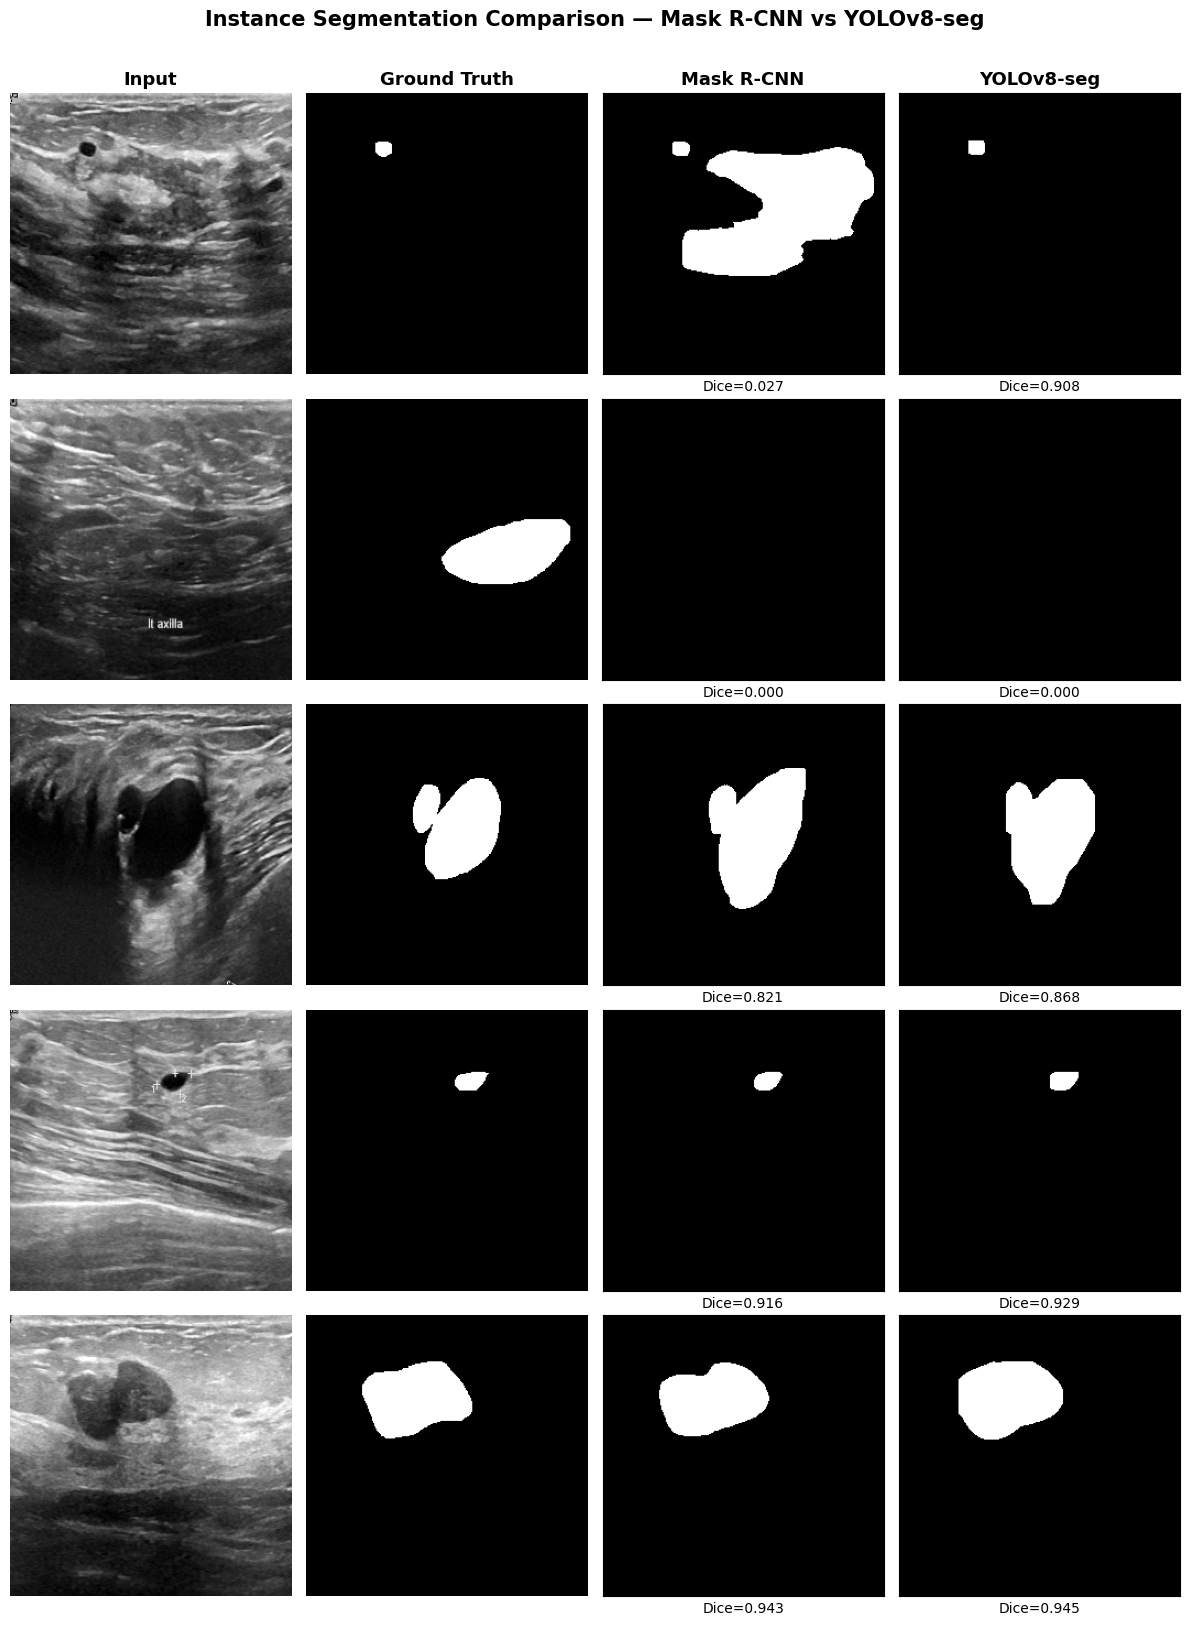

In [25]:
n_samples = 5
fig, axes = plt.subplots(n_samples, 4, figsize=(12, 3.2 * n_samples))

col_titles = ['Input', 'Ground Truth', 'Mask R-CNN', 'YOLOv8-seg']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=13, fontweight='bold')

for row, i in enumerate(idx_test[:n_samples]):
    img_u8 = imgs_raw[i]
    gt = masks[i, ..., 0]

    axes[row, 0].imshow(img_u8, cmap='gray')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(gt, cmap='gray')
    axes[row, 1].axis('off')

    mrcnn_pred = mrcnn_preds_store[i]
    d_mrcnn = dice_score(gt, mrcnn_pred)
    axes[row, 2].imshow(mrcnn_pred, cmap='gray')
    axes[row, 2].set_xlabel(f'Dice={d_mrcnn:.3f}', fontsize=10)
    axes[row, 2].set_xticks([]); axes[row, 2].set_yticks([])

    yolo_pred = yolo_preds_store[i]
    d_yolo = dice_score(gt, yolo_pred)
    axes[row, 3].imshow(yolo_pred, cmap='gray')
    axes[row, 3].set_xlabel(f'Dice={d_yolo:.3f}', fontsize=10)
    axes[row, 3].set_xticks([]); axes[row, 3].set_yticks([])

plt.suptitle('Instance Segmentation Comparison — Mask R-CNN vs YOLOv8-seg', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('instance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
import os
print("Current working directory:", os.getcwd())
print(os.path.exists('instance_comparison.png'))

Current working directory: /content/yolact
True
